# B2_S01 — Why Pandas Breaks

## Opening hook

The CEO wants the dashboard at **9:00 AM**.

It is **8:47 AM**.

Your notebook has been running for twelve minutes. The fan is screaming. The progress bar is not moving. You try to rerun the groupby. The kernel dies.

Nothing is wrong with your business question. Nothing is wrong with pandas either.

The problem is architectural: you are asking a single-machine, in-memory tool to behave like a production data platform.

**Final lesson:** Big Data starts when pandas stops being enough.

## Decision problem

How do we know when a pandas notebook has become a data engineering problem?

This session starts with failure, not Hadoop theory. Students should feel the pain first: CSV loading, slow groupbys, expensive joins, RAM pressure, and temporary copies.

In [1]:
from pathlib import Path
import time
import tracemalloc
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
SNAPSHOT = "iot_FR_today_5-y_chatgpt_iphone_meteo.csv"
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "data" / "snapshots" / SNAPSHOT).exists():
        ROOT = candidate
        break
OUT = ROOT / "outputs" / "bloc2" / "why_pandas_breaks"
OUT.mkdir(parents=True, exist_ok=True)
DEMO_DIR = Path(tempfile.gettempdir()) / "ai_course_why_pandas_breaks"
DEMO_DIR.mkdir(parents=True, exist_ok=True)
print("Output folder:", OUT)
print("Temporary demo data:", DEMO_DIR)

Output folder: /Users/mathieu/Project/03_AI_Media/AI-course/outputs/bloc2/why_pandas_breaks
Temporary demo data: /var/folders/8f/wl2jjc855rd8qvgsnklpqkyr0000gn/T/ai_course_why_pandas_breaks


# Stage 1 — It breaks

A realistic dashboard starts simply: load transactions from CSV, join customer/product tables, compute revenue by month/country/channel/category, and export dashboard tables.

At small scale, pandas feels magical. At larger scale, the same logic becomes fragile.

In [2]:
N_TRANSACTIONS = 350_000
N_CUSTOMERS = 60_000
N_PRODUCTS = 1_500
rng = np.random.default_rng(42)

def timed_step(label, fn):
    tracemalloc.start()
    start = time.perf_counter()
    result = fn()
    elapsed = time.perf_counter() - start
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return result, {"step": label, "seconds": round(elapsed, 3), "python_peak_mb": round(peak / 1024 / 1024, 1)}

transactions_path = DEMO_DIR / "transactions_large.csv"
customers_path = DEMO_DIR / "customers.csv"
products_path = DEMO_DIR / "products.csv"

if not transactions_path.exists():
    dates = pd.date_range("2024-01-01", periods=365, freq="D")
    transactions_seed = pd.DataFrame({
        "order_id": np.arange(N_TRANSACTIONS),
        "customer_id": rng.integers(1, N_CUSTOMERS + 1, size=N_TRANSACTIONS),
        "product_id": rng.integers(1, N_PRODUCTS + 1, size=N_TRANSACTIONS),
        "order_date": rng.choice(dates, size=N_TRANSACTIONS),
        "quantity": rng.integers(1, 6, size=N_TRANSACTIONS),
        "unit_price": rng.gamma(shape=3.0, scale=18.0, size=N_TRANSACTIONS).round(2),
        "discount_rate": rng.choice([0, 0.05, 0.10, 0.20], size=N_TRANSACTIONS, p=[0.55, 0.2, 0.18, 0.07]),
        "channel": rng.choice(["web", "store", "partner", "mobile"], size=N_TRANSACTIONS, p=[0.45, 0.25, 0.15, 0.15]),
    })
    customers_seed = pd.DataFrame({
        "customer_id": np.arange(1, N_CUSTOMERS + 1),
        "country": rng.choice(["FR", "DE", "ES", "IT", "NL", "BE"], size=N_CUSTOMERS, p=[0.45, 0.15, 0.12, 0.10, 0.10, 0.08]),
        "segment": rng.choice(["SMB", "midmarket", "enterprise"], size=N_CUSTOMERS, p=[0.65, 0.25, 0.10]),
    })
    products_seed = pd.DataFrame({
        "product_id": np.arange(1, N_PRODUCTS + 1),
        "category": rng.choice(["AI tools", "hardware", "software", "services", "training"], size=N_PRODUCTS),
        "margin_rate": rng.uniform(0.15, 0.75, size=N_PRODUCTS).round(2),
    })
    transactions_seed.to_csv(transactions_path, index=False)
    customers_seed.to_csv(customers_path, index=False)
    products_seed.to_csv(products_path, index=False)

pd.DataFrame([{"file": p.name, "size_mb": round(p.stat().st_size / 1024 / 1024, 2)} for p in [transactions_path, customers_path, products_path]])

,file,size_mb
0,transactions_large.csv,15.18
1,customers.csv,0.86
2,products.csv,0.03


## 1. Large CSV loading

CSV is convenient, but painful at scale: text parsing, type inference, no column pruning, and weak schema guarantees.

In [3]:
measurements = []
transactions, m = timed_step("read large transactions CSV", lambda: pd.read_csv(transactions_path)); measurements.append(m)
customers, m = timed_step("read customers CSV", lambda: pd.read_csv(customers_path)); measurements.append(m)
products, m = timed_step("read products CSV", lambda: pd.read_csv(products_path)); measurements.append(m)

pd.DataFrame({
    "table": ["transactions", "customers", "products"],
    "rows": [len(transactions), len(customers), len(products)],
    "memory_mb": [transactions.memory_usage(deep=True).sum()/1024/1024, customers.memory_usage(deep=True).sum()/1024/1024, products.memory_usage(deep=True).sum()/1024/1024],
}).round(2)

,table,rows,memory_mb
0,transactions,350000,53.59
1,customers,60000,6.48
2,products,1500,0.10


## 2. Slow groupby pressure

The dashboard asks for revenue by month and channel. That requires date parsing, derived columns, and aggregation.

In [4]:
def pandas_groupby_workload():
    df = transactions.copy()
    df["order_date"] = pd.to_datetime(df["order_date"])
    df["month"] = df["order_date"].dt.to_period("M").astype(str)
    df["gross_revenue"] = df["quantity"] * df["unit_price"]
    df["net_revenue"] = df["gross_revenue"] * (1 - df["discount_rate"])
    return df.groupby(["month", "channel"], as_index=False).agg(orders=("order_id", "count"), net_revenue=("net_revenue", "sum"), avg_order_value=("net_revenue", "mean"))

grouped, m = timed_step("pandas groupby dashboard table", pandas_groupby_workload)
measurements.append(m)
grouped.head()

,month,channel,orders,net_revenue,avg_order_value
0,2024-01,mobile,4367,6.942750e+05,158.982142
1,2024-01,partner,4399,6.883424e+05,156.477019
2,2024-01,store,7476,1.149781e+06,153.796279
3,2024-01,web,13403,2.089735e+06,155.915478
4,2024-02,mobile,4138,6.590926e+05,159.278052


## 3. Expensive joins and temporary copies

Joins are where notebook code starts to feel production-shaped. A merge can duplicate columns, allocate temporary arrays, and multiply memory pressure before the final table exists.

In [5]:
def pandas_join_workload():
    enriched = transactions.merge(customers, on="customer_id", how="left").merge(products, on="product_id", how="left")
    enriched["order_date"] = pd.to_datetime(enriched["order_date"])
    enriched["month"] = enriched["order_date"].dt.to_period("M").astype(str)
    enriched["net_revenue"] = enriched["quantity"] * enriched["unit_price"] * (1 - enriched["discount_rate"])
    enriched["gross_margin"] = enriched["net_revenue"] * enriched["margin_rate"]
    dashboard = enriched.groupby(["month", "country", "segment", "category", "channel"], as_index=False).agg(orders=("order_id", "count"), revenue=("net_revenue", "sum"), margin=("gross_margin", "sum"))
    return enriched, dashboard

(enriched, dashboard), m = timed_step("joins + multi-dimensional dashboard", pandas_join_workload)
measurements.append(m)

pd.DataFrame([
    {"object": "transactions", "memory_mb": transactions.memory_usage(deep=True).sum()/1024/1024},
    {"object": "enriched after joins", "memory_mb": enriched.memory_usage(deep=True).sum()/1024/1024},
    {"object": "dashboard output", "memory_mb": dashboard.memory_usage(deep=True).sum()/1024/1024},
]).round(2)

,object,memory_mb
0,transactions,53.59
1,enriched after joins,117.41
2,dashboard output,1.23


## 4. The hurt, summarized

Pandas is built for single-machine, in-memory analytics. It often creates temporary copies, and those copies can multiply memory usage significantly.

When the dataset grows from thousands to millions to billions of rows, the notebook does not slowly become elegant. It becomes brittle.

In [6]:
comparison = pd.DataFrame(measurements)
comparison["what_hurts"] = [
    "CSV text parsing and type inference",
    "dimension table still fits, but adds join cost",
    "small table, but required for enrichment",
    "groupby creates derived columns and aggregation work",
    "joins create large intermediate tables and memory pressure",
]
comparison.to_csv(OUT / "comparison_summary.csv", index=False)
comparison

,step,seconds,python_peak_mb,what_hurts
0,read large transactions CSV,0.230,64.3,CSV text parsing and type inference
1,read customers CSV,0.016,3.8,"dimension table still fits, but adds join cost"
2,read products CSV,0.003,0.3,"small table, but required for enrichment"
3,pandas groupby dashboard table,2.787,69.9,groupby creates derived columns and aggregatio...
4,joins + multi-dimensional dashboard,2.800,88.7,joins create large intermediate tables and mem...


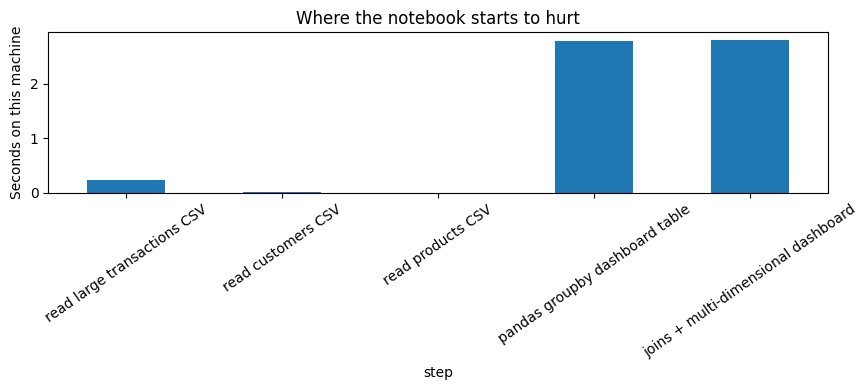

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
comparison.plot.bar(x="step", y="seconds", ax=ax, legend=False)
ax.set_title("Where the notebook starts to hurt")
ax.set_ylabel("Seconds on this machine")
ax.tick_params(axis="x", labelrotation=35)
fig.tight_layout()
fig.savefig(OUT / "pandas_breakdown_timing.png", dpi=140)
plt.show()

# Stage 2 — Why it breaks

The problem is not that pandas is bad. The problem is that the architecture is wrong for the workload.

- **RAM limits:** pandas wants data in memory; joins, strings, derived columns, and filters can create copies.
- **CPU limits:** one machine has limited cores.
- **Vertical scaling limits:** buying a bigger machine works until it becomes too expensive or fragile.
- **I/O bottlenecks:** CSV forces repeated text parsing.
- **Operational limits:** a notebook on one machine is not a reliable 9AM dashboard pipeline.

In [8]:
growth = pd.DataFrame({"rows": [350_000, 3_500_000, 35_000_000, 350_000_000]})
base_memory = transactions.memory_usage(deep=True).sum() / 1024 / 1024
growth["estimated_raw_memory_gb"] = (base_memory * (growth["rows"] / len(transactions)) / 1024).round(2)
growth["with_joins_and_copies_gb_estimate"] = (growth["estimated_raw_memory_gb"] * 4).round(2)
growth

,rows,estimated_raw_memory_gb,with_joins_and_copies_gb_estimate
0,350000,0.05,0.20
1,3500000,0.52,2.08
2,35000000,5.23,20.92
3,350000000,52.33,209.32


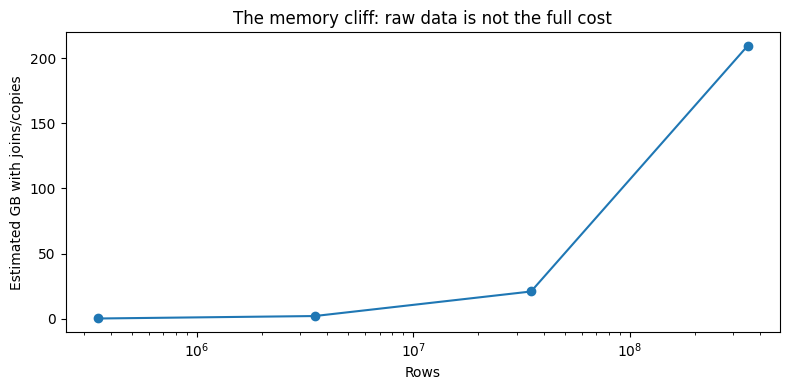

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(growth["rows"], growth["with_joins_and_copies_gb_estimate"], marker="o")
ax.set_xscale("log")
ax.set_title("The memory cliff: raw data is not the full cost")
ax.set_xlabel("Rows")
ax.set_ylabel("Estimated GB with joins/copies")
fig.tight_layout()
fig.savefig(OUT / "memory_cliff.png", dpi=140)
plt.show()

# Stage 3 — What changes everything

Big Data tools are not magic. They change the execution model.

- **Parquet:** typed, columnar storage; less repeated parsing.
- **Partitioning:** skip irrelevant slices such as dates or countries.
- **Distributed compute:** split work across partitions and machines.
- **Spark mindset:** define transformations, let the engine plan execution.
- **Bronze → Silver → Gold:** raw data, clean validated data, business-ready outputs.

This is why Hadoop/Spark exist. Not because theory says so, but because the 9AM dashboard cannot depend on one dying notebook.

In [10]:
parquet_note = '# Parquet vs CSV Note\n\nCSV is easy to exchange but painful at scale: text parsing, weak schema, no efficient column pruning.\n\nParquet is better for analytical pipelines: typed columns, compression, columnar reads, and stronger compatibility with distributed engines.\n\nTeaching recommendation: use CSV for first contact, then move curated data to Parquet when repeatability and performance matter.\n'
(OUT / "parquet_vs_csv_note.md").write_text(parquet_note)

try:
    enriched.to_parquet(DEMO_DIR / "silver_transactions.parquet", index=False)
    parquet_status = "created"
except Exception as exc:
    parquet_status = f"skipped: {type(exc).__name__}"

architecture_note = '# Architecture Note\n\nPain observed: pandas handles the first analysis, but joins, groupbys, and repeated CSV loading create RAM and runtime pressure.\n\nArchitecture response:\n- Bronze: keep raw CSV exports.\n- Silver: create typed cleaned Parquet tables.\n- Gold: publish dashboard-ready aggregates.\n- Monitoring: track freshness, row counts, schema, and failed joins.\n\nBig Data starts when single-machine notebooks are no longer reliable enough for the decision process.\n'
(OUT / "architecture_note.md").write_text(architecture_note)
print("Parquet status:", parquet_status)

Parquet status: created


# Stage 4 — Minimal real Spark credibility

You do not need a Hadoop installation to understand the shift.

The key idea: Spark expresses the same business logic as transformations over distributed DataFrames.

In [11]:
spark_code = '# Optional: run in Colab or local PySpark if available.\nfrom pyspark.sql import SparkSession\nfrom pyspark.sql.functions import col, month, sum as spark_sum, count\n\nspark = SparkSession.builder.appName("why-pandas-breaks").getOrCreate()\ntransactions = spark.read.option("header", True).option("inferSchema", True).csv("transactions_large.csv")\ncustomers = spark.read.option("header", True).option("inferSchema", True).csv("customers.csv")\nproducts = spark.read.option("header", True).option("inferSchema", True).csv("products.csv")\n\ngold = (\n    transactions\n    .join(customers, "customer_id", "left")\n    .join(products, "product_id", "left")\n    .withColumn("net_revenue", col("quantity") * col("unit_price") * (1 - col("discount_rate")))\n    .withColumn("month", month(col("order_date")))\n    .groupBy("month", "country", "segment", "category", "channel")\n    .agg(count("order_id").alias("orders"), spark_sum("net_revenue").alias("revenue"))\n)\n\ngold.show(10)'
print(spark_code)

# Optional: run in Colab or local PySpark if available.
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, month, sum as spark_sum, count

spark = SparkSession.builder.appName("why-pandas-breaks").getOrCreate()
transactions = spark.read.option("header", True).option("inferSchema", True).csv("transactions_large.csv")
customers = spark.read.option("header", True).option("inferSchema", True).csv("customers.csv")
products = spark.read.option("header", True).option("inferSchema", True).csv("products.csv")

gold = (
    transactions
    .join(customers, "customer_id", "left")
    .join(products, "product_id", "left")
    .withColumn("net_revenue", col("quantity") * col("unit_price") * (1 - col("discount_rate")))
    .withColumn("month", month(col("order_date")))
    .groupBy("month", "country", "segment", "category", "channel")
    .agg(count("order_id").alias("orders"), spark_sum("net_revenue").alias("revenue"))
)

gold.show(10)


In [12]:
try:
    from pyspark.sql import SparkSession
    from pyspark.sql.functions import col, month, sum as spark_sum, count

    spark = SparkSession.builder.master("local[*]").appName("why-pandas-breaks").getOrCreate()
    spark_transactions = spark.read.option("header", True).option("inferSchema", True).csv(str(transactions_path))
    spark_customers = spark.read.option("header", True).option("inferSchema", True).csv(str(customers_path))
    spark_products = spark.read.option("header", True).option("inferSchema", True).csv(str(products_path))
    spark_gold = (
        spark_transactions
        .join(spark_customers, "customer_id", "left")
        .join(spark_products, "product_id", "left")
        .withColumn("net_revenue", col("quantity") * col("unit_price") * (1 - col("discount_rate")))
        .withColumn("month", month(col("order_date")))
        .groupBy("month", "country", "segment", "category", "channel")
        .agg(count("order_id").alias("orders"), spark_sum("net_revenue").alias("revenue"))
    )
    spark_result = spark_gold.limit(10).toPandas()
    spark_status = "executed locally"
    spark.stop()
except Exception as exc:
    spark_result = pd.DataFrame({"message": ["PySpark not available locally. Use the displayed Spark syntax in Colab or a Spark environment."], "reason": [type(exc).__name__]})
    spark_status = "pseudocode path used"

spark_result.to_csv(OUT / "spark_demo_status.csv", index=False)
print("Spark status:", spark_status)
spark_result

Spark status: pseudocode path used


,message,reason
0,PySpark not available locally. Use the display...,ModuleNotFoundError


# Pipeline recommendation

The 9AM dashboard should not depend on a fragile notebook rerun.

Recommended pipeline:

1. **Bronze:** land raw CSV exports unchanged.
2. **Silver:** validate schema, parse dates, type numeric columns, write Parquet.
3. **Gold:** build dashboard aggregates by month, country, segment, category, and channel.
4. **Monitoring:** check row counts, freshness, failed joins, and output size.
5. **Serving:** BI reads Gold tables, not raw CSV files.

In [13]:
pipeline_recommendation = '# Pipeline Recommendation\n\nDo not run the CEO dashboard directly from raw CSV in a notebook.\n\nUse a Bronze -> Silver -> Gold pipeline:\n1. Bronze: raw CSV exports preserved.\n2. Silver: cleaned typed Parquet tables.\n3. Gold: dashboard aggregates.\n4. Monitoring: freshness, row counts, schema checks, failed joins.\n\nSpark or another distributed engine becomes justified when single-machine pandas is too slow, too memory-heavy, or too unreliable for the decision deadline.\n'
(OUT / "pipeline_recommendation.md").write_text(pipeline_recommendation)

artifact_summary = pd.DataFrame([
    {"artifact": "comparison_summary.csv", "purpose": "show where pandas hurts"},
    {"artifact": "architecture_note.md", "purpose": "explain why architecture matters"},
    {"artifact": "parquet_vs_csv_note.md", "purpose": "compare storage choices"},
    {"artifact": "pipeline_recommendation.md", "purpose": "recommend production direction"},
    {"artifact": "spark_demo_status.csv", "purpose": "show Spark syntax/path"},
])
artifact_summary.to_csv(OUT / "artifact_summary.csv", index=False)
artifact_summary

,artifact,purpose
0,comparison_summary.csv,show where pandas hurts
1,architecture_note.md,explain why architecture matters
2,parquet_vs_csv_note.md,compare storage choices
3,pipeline_recommendation.md,recommend production direction
4,spark_demo_status.csv,show Spark syntax/path


## Practical exercise

Take the dashboard problem and answer:

1. Which step is Bronze?
2. Which table is Silver?
3. Which output is Gold?
4. What would you monitor before the CEO opens the dashboard?
5. At what point would pandas stop being enough?

## Conclusion

Pandas is excellent until the workload becomes too large, too repeated, or too important to depend on a single machine.

Students should leave remembering one sentence:

**Big Data starts when pandas stops being enough.**